## Loading the Data ##

In [43]:
#Necessary packages
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Intra-day for our stock today
ticker = 'TSLA'
#stock = yf.download(ticker, interval = '1d', period = '1d') 
stock = yf.download(ticker, interval = '1d')

[*********************100%***********************]  1 of 1 completed


In [44]:
#Debugging
if len(stock.columns.names) != 1:
    stock.columns = stock.columns.droplevel('Ticker')

In [45]:
stock['Log Returns'] = np.log(stock['Close']/stock['Close'].shift(1))
stock = stock.dropna()

In [49]:
close = stock['Close'].values[-100:] #Converts our values to an array
returns = stock['Log Returns'].values

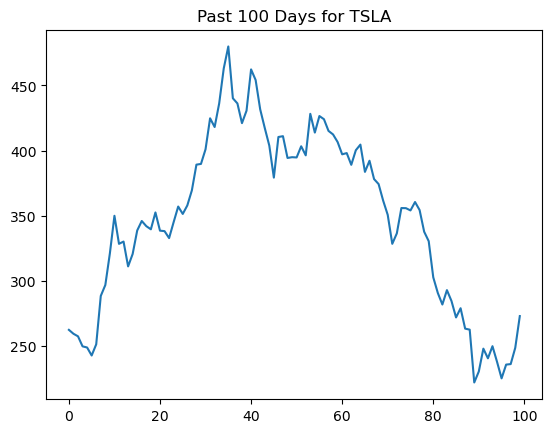

In [51]:
plt.plot(close);
plt.title('Past 100 Days for ' + str(ticker));

## Testing the Efficacy of our Geometric Brownian Motion (GBM) Model for Today ##

In [54]:
#Defining initial parameters for GBM
mean_returns = np.mean(returns)
volatility = np.std(returns)
dt = 1 #1-minute time frames

In [56]:
def gbm(forecast_horizon, start, mean_returns, volatility, dt):
    """Performs one prediction."""
    
    #Initializing parameters 
    values = []
    dwt = np.random.normal(loc = 0, scale = np.sqrt(dt), size = 1)

    #Forecast
    for i in range(forecast_horizon):
        #Calculating the next price
        next_point = start * np.exp((mean_returns - 0.5 * volatility ** 2) +  volatility * np.sqrt(dt) * dwt)
        values.append(next_point)

        #Updating variables
        start = next_point
        dwt = np.random.normal(loc = 0, scale = np.sqrt(dt), size = 1) 

    #Simulated Markov Chain
    return values 

In [58]:
N = 5_000 #Number of simulations

def test_gbm(N, mean_returns, volatility, dt):
    """Uses Mean Absolute Percentage Error and R-squared to test how effective GBM has been in modeling all stock prices of the day thus far."""
    
    #Only import this metric if testing is to be performed
    from sklearn.metrics import mean_absolute_percentage_error, r2_score

    mape = []
    correlations = []
    for i in range(N):
        #MAPE
        forecast = gbm(forecast_horizon = len(close), start = close[0], mean_returns = mean_returns, volatility = volatility, dt = dt)
        error = mean_absolute_percentage_error(y_true = close, y_pred = forecast)

        #Saving results
        mape.append(error)
        correlations.append(r2_score(y_true = close, y_pred = forecast))
        

    return mape, correlations

In [60]:
mape, correlations = test_gbm(N, mean_returns = mean_returns, volatility = volatility, dt = dt)

In [61]:
#Average of Mean Absolute Percentage Errors
print('Mean Absolute Percentage Error (in Percentage): ' + str(np.mean(mape) * 100) + '%') 

Mean Absolute Percentage Error (in Percentage): 27.960694541215066%


## Confidence Interval for Price ##

In [63]:
def confidence_interval(num_sims, alpha, forecast_horizon, mean_returns, volatility, dt):
    
    #Perform simulations 
    simulations = []
    for i in range(num_sims):
        forecast = gbm(forecast_horizon = forecast_horizon, start = close[-1], mean_returns = mean_returns, volatility = volatility, dt = dt)
        simulations.append(forecast)

        #Visual Analysis
        plt.plot(forecast)
        
    simulations = np.array(simulations)
    plt.title('Geometric Brownian Forecasts')
    
    #Confidence Interval
    end_vals = simulations[:, -1]
    lower_bound = np.percentile(a = end_vals, q = alpha/2)
    upper_bound = np.percentile(a = end_vals, q = 1 - (alpha/2))

    return end_vals, lower_bound, upper_bound

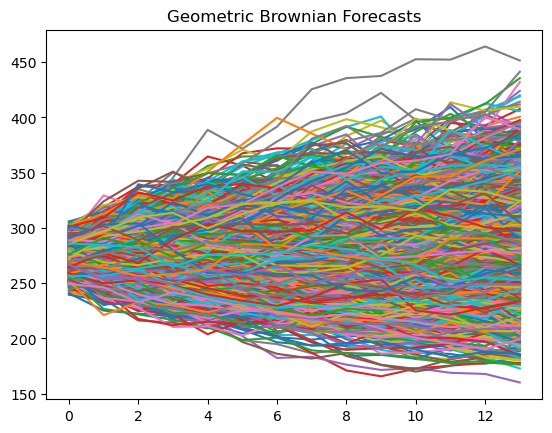

In [64]:
end_vals, lower_bound, upper_bound = confidence_interval(num_sims = N, alpha = 0.05, forecast_horizon = 14, mean_returns = mean_returns, volatility = volatility, dt = 1)

In [65]:
lower_bound, upper_bound

(173.7491305382262, 201.4446415345309)

In [66]:
#Probability (based on simulations) that the stock will drop
p_value = np.sum(end_vals <= close[-1]) / len(end_vals)
p_value

0.468

In [67]:
#Value at Risk
np.percentile(end_vals, 0.05)

176.48957746703763